In [292]:
import pandas as pd
import os
import matplotlib.pyplot as plot
import seaborn as sns

pd.set_option("mode.copy_on_write", True)

In [352]:
def parse_number(s):
    if pd.isna(s):
        return None
    s = str(s).strip().upper()
    if s.endswith("K"):
        return float(s[:-1]) * 1_000
    elif s.endswith("M"):
        return float(s[:-1]) * 1_000_000
    elif s.endswith("B"):
        return float(s[:-1]) * 1_000_000_000
    else:
        return float(s)


def get_property_damage_value(dataset):

    dataset["DAMAGE_PROPERTY"] = dataset["DAMAGE_PROPERTY"].apply(
        lambda x: (
            "1K"
            if pd.notna(x) and x == "K"
            else ("1M" if pd.notna(x) and x == "M" else x)
        )
    )

    dataset["DAMAGE_PROPERTY_VALUE"] = dataset["DAMAGE_PROPERTY"].apply(parse_number)

    print(len(dataset[dataset["DAMAGE_PROPERTY_VALUE"] > 0]))

    dataset["COUNT"] = dataset.groupby(["CZ_NAME", "YEAR"])["CZ_NAME"].transform(
        "count"
    )
    dataset["DAMAGE_PROPERTY_VALUE"] = dataset["DAMAGE_PROPERTY_VALUE"].fillna(0)
    dataset["DAMAGE_PROPERTY_VALUE"] = dataset["DAMAGE_PROPERTY_VALUE"].astype(float)

    # Group by COUNTY and summarize
    county_summary = (
        dataset.groupby(["FIPS", "YEAR"], as_index=False)
        .agg(
            {
                "COUNT": "first",
                "CZ_NAME": "first",
                "STATE": "first",
                "STATE_FIPS": "first",
                "DAMAGE_PROPERTY_VALUE": "sum",
                "DURATION_HOURS": "sum",
                "COUNT": "first",
            }
        )
        .rename(
            columns={
                "DAMAGE_PROPERTY_VALUE": "TOTAL_DAMAGE_PROPERTY",
                "DURATION_HOURS": "TOTAL_DURATION_HOURS",
            }
        )
    )

    return county_summary

In [294]:
nws_zone_fips_ref = pd.read_csv(
    "../../01_original_data/fema_storm_data/county_zone_reference/bp18mr25.dbx.txt",
    delimiter="|",
    header=None,
)
states = pd.read_csv(
    "../../01_original_data/fema_storm_data/county_zone_reference/states.csv"
)
states["FIPS"] = states["FIPS"].apply(lambda x: str(x).zfill(2))

nws_zone_fips_ref.columns = [
    "STATE",  # Two character state abbreviation
    "ZONE",  # Three character zone number
    "CWA",  # Three character CWA ID (of the zone, starting with 01 May 2018 file)
    "NAME",  # Zone name
    "STATE_ZONE",  # 5 character state + three character zone number
    "COUNTY",  # County name
    "FIPS",  # 5 character state-county FIPS code
    "TIME_ZONE",  # Time zone of polygon (See comments on county page)
    "FE_AREA",  # Feature Area (location in STATE - See comments on county page)
    "LAT",  # Latitude of centroid of the zone
    "LON",  # Longitude of centroid of the zone
]

nws_zone_fips_ref

,STATE,ZONE,CWA,NAME,STATE_ZONE,COUNTY,FIPS,TIME_ZONE,FE_AREA,LAT,LON
0,NM,201,ABQ,Northwest Plateau,NM201,McKinley,35031,M,nw,36.4270,-108.4064
1,NM,201,ABQ,Northwest Plateau,NM201,San Juan,35045,M,nw,36.4270,-108.4064
2,NM,202,ABQ,Chuska Mountains,NM202,McKinley,35031,M,nw,36.0409,-108.9296
3,NM,202,ABQ,Chuska Mountains,NM202,San Juan,35045,M,nw,36.0409,-108.9296
4,NM,203,ABQ,Far Northwest Highlands,NM203,Rio Arriba,35039,M,nc,36.6585,-107.1028
...,...,...,...,...,...,...,...,...,...,...,...
4831,FL,233,JAX,Northeast Coastal St. Johns,FL223,St. Johns,12109,E,ne,30.0922,-81.3753
4832,FL,333,JAX,Southeast Coastal St. Johns,FL333,St. Johns,12109,E,ne,29.7778,-81.2954
4833,FL,433,JAX,Northern Inland St. Johns,FL433,St. Johns,12109,E,ne,30.0120,-81.4554
4834,FL,533,JAX,Southern Inland St. Johns,FL533,St. Johns,12109,E,ne,29.7856,-81.4103


In [295]:
data_files = [
    f
    for f in os.listdir("../../01_original_data/fema_storm_data/")
    if f.endswith(".parquet")
]

storm = pd.concat(
    [
        pd.read_parquet(os.path.join("../../01_original_data/fema_storm_data/", f))
        for f in data_files
    ],
    axis=0,
    ignore_index=True,
)

storm = storm.drop(storm[storm["CZ_TYPE"] == "M"].index)
storm = storm.drop(storm[storm["STATE_FIPS"].isna()].index)

storm["STATE_FIPS"] = storm["STATE_FIPS"].astype(int).astype(str).str.zfill(2)
storm["CZ_FIPS"] = storm["CZ_FIPS"].astype(int).astype(str).str.zfill(3)

# Remove Puerto Rico and other territories
storm = storm[storm["STATE_FIPS"].isin(states["FIPS"].tolist())]


storm.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,200111,28,600,200111,29,1800,1124964.0,5274875,TEXAS,48,...,NaN,None,None,NaN,NaN,NaN,NaN,Late on the 26th and on the 27th an arctic col...,Cooperative observer reported one inch of snow.,PDS
2,200112,1,900,200112,1,1800,1125247.0,5275049,NEW JERSEY,34,...,NaN,None,None,NaN,NaN,NaN,NaN,A strong ridge of high pressure over the weste...,None,PDS
3,200111,29,600,200111,29,1800,1124964.0,5274877,TEXAS,48,...,NaN,None,None,NaN,NaN,NaN,NaN,Late on the 26th and on the 27th an arctic col...,A mixture of freezing rain and sleet made brid...,PDS
4,200111,15,800,200111,30,800,1125105.0,5274892,SOUTH CAROLINA,45,...,NaN,None,None,NaN,NaN,NaN,NaN,None,The South Carolina Drought Response Committee ...,PDS
5,200111,15,800,200111,30,800,1125105.0,5274893,SOUTH CAROLINA,45,...,NaN,None,None,NaN,NaN,NaN,NaN,None,None,PDS


### Get the FIPS codes for flood events and also convert zone FIPS to county FIPS

In [296]:
def get_fips(row):
    if row["CZ_TYPE"] == "Z":
        match = nws_zone_fips_ref.loc[
            nws_zone_fips_ref["STATE_ZONE"]
            == (
                states.loc[states["FIPS"] == row["STATE_FIPS"], "Postal"]
                .reset_index(drop=True)
                .get(0, "")
                + row["CZ_FIPS"]
            ),
            "FIPS",
        ]
        return match.iloc[0] if not match.empty else None
    else:
        return row["STATE_FIPS"] + row["CZ_FIPS"]


storm["FIPS"] = storm.apply(get_fips, axis=1)

In [365]:
flood = storm[storm["EVENT_TYPE"].str.contains("flood", case=False)]

### Calculate duration of flood events

In [366]:
flood["begin_dt_str".upper()] = (
    flood["begin_yearmonth".upper()].astype(str)
    + flood["begin_day".upper()].astype(str).str.zfill(2)
    + flood["begin_time".upper()].astype(str).str.zfill(4)
)

flood["end_dt_str".upper()] = (
    flood["end_yearmonth".upper()].astype(str)
    + flood["end_day".upper()].astype(str).str.zfill(2)
    + flood["end_time".upper()].astype(str).str.zfill(4)
)

In [ ]:
flood["begin_dt".upper()] = pd.to_datetime(
    flood["begin_dt_str".upper()], format="%Y%m%d%H%M", errors="coerce"
)
flood["end_dt".upper()] = pd.to_datetime(
    flood["end_dt_str".upper()], format="%Y%m%d%H%M", errors="coerce"
)
flood["DURATION_HOURS"] = (
    flood["end_dt".upper()] - flood["begin_dt".upper()]
).dt.total_seconds() / 3600
flood = flood.drop(columns=["begin_dt_str".upper(), "end_dt_str".upper()])

In [368]:
flood = get_property_damage_value(flood)
flood

57623


,FIPS,YEAR,COUNT,CZ_NAME,STATE,STATE_FIPS,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,1001,2005,3,AUTAUGA,ALABAMA,01,0.0,71.000000
1,1003,2024,4,BALDWIN CENTRAL,ALABAMA,01,0.0,0.000000
2,1007,2005,3,BIBB,ALABAMA,01,0.0,71.000000
3,1017,2003,8,CHAMBERS,ALABAMA,01,2525000.0,114.500000
4,1017,2005,3,CHAMBERS,ALABAMA,01,1000.0,96.000000
...,...,...,...,...,...,...,...,...
41880,56045,2012,1,WESTON,WYOMING,56,5000.0,1.000000
41881,56045,2013,3,WESTON,WYOMING,56,135000.0,8.333333
41882,56045,2015,4,WESTON,WYOMING,56,30000.0,37.083333
41883,56045,2018,1,WESTON,WYOMING,56,0.0,40.083333


In [ ]:
flood = flood[
    [
        "FIPS",
        "YEAR",
        "STATE",
        "CZ_NAME",
        "COUNT",
        "TOTAL_DAMAGE_PROPERTY",
        "TOTAL_DURATION_HOURS",
    ]
]
flood = flood[(flood["YEAR"] >= 2000) & (flood["YEAR"] <= 2020)]

flood["TOTAL_DURATION_HOURS"] = flood["TOTAL_DURATION_HOURS"].round(2)

# flood.to_csv(
#     "../../02_processed_data/fema_flood_county_2000.csv",
#     index=False,
# )
flood.head()

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,01001,2005,ALABAMA,AUTAUGA,3,0.0,71.0
2,01007,2005,ALABAMA,BIBB,3,0.0,71.0
3,01017,2003,ALABAMA,CHAMBERS,8,2525000.0,114.5
4,01017,2005,ALABAMA,CHAMBERS,3,1000.0,96.0
6,01047,2005,ALABAMA,DALLAS,6,15000.0,71.0


In [ ]:
flood_state = (
    flood[(flood["YEAR"] >= 2000) & (flood["YEAR"] <= 2020)]
    .groupby("STATE")
    .agg(
        {"TOTAL_DAMAGE_PROPERTY": "sum", "TOTAL_DURATION_HOURS": "sum", "COUNT": "sum"}
    )
    .sort_values(by="TOTAL_DAMAGE_PROPERTY", ascending=False)
)
flood_state = flood_state.reset_index()


def get_state_abbrev(cell):
    return (
        states.loc[states["State"].str.lower() == cell.lower(), "Postal"]
        .reset_index(drop=True)
        .get(0, "")
    )


# flood_state["STATE"] = flood_state["STATE"].apply(lambda cell: get_state_abbrev(cell))
flood_state["STATE"] = flood_state["STATE"].apply(lambda cell: cell.capitalize())
flood_state

,STATE,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,COUNT
0,Texas,4.786991e+10,63964.60,17013
1,New jersey,2.253624e+10,20261.95,4313
2,Louisiana,1.004910e+10,48347.40,6675
3,Tennessee,4.795486e+09,18722.43,12814
4,New york,2.926523e+09,62949.90,10260
5,Michigan,2.887904e+09,34690.40,2905
6,California,1.997171e+09,20331.45,3741
7,Pennsylvania,1.752724e+09,27797.48,12181
8,Iowa,1.748281e+09,451228.82,17833
9,Florida,1.745424e+09,19787.90,5088


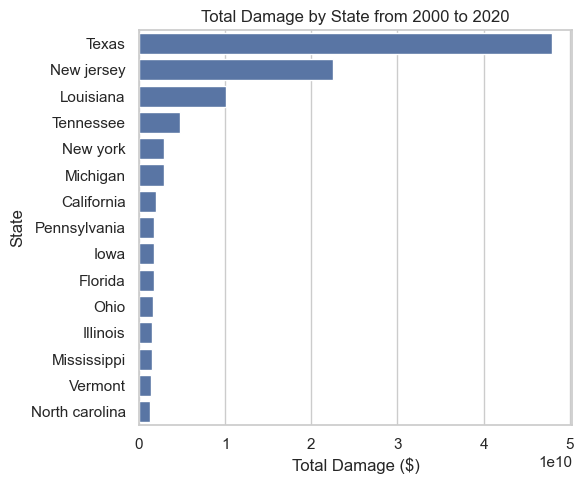

In [415]:
flood_state = flood_state.sort_values(by="TOTAL_DAMAGE_PROPERTY", ascending=False)
sns.set_theme(style="whitegrid")
plot.figure(figsize=(6, 5))
plot.title("Total Damage by State from 2000 to 2020")
plot.xlabel("Total Damage ($)")
plot.ylabel("State")
to_plot = flood_state.head(15)
sns.barplot(y=to_plot["STATE"], x=to_plot["TOTAL_DAMAGE_PROPERTY"])
plot.tight_layout()
plot.show()

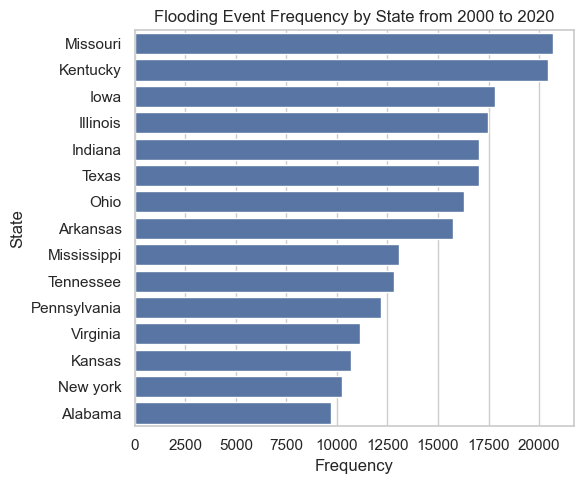

In [412]:
flood_state_count_sorted = flood_state.sort_values(by="COUNT", ascending=False)
plot.figure(figsize=(6, 5))
plot.title("Flooding Event Frequency by State from 2000 to 2020")
plot.ylabel("State")
plot.xlabel("Frequency")
to_plot = flood_state_count_sorted.head(15)
sns.barplot(y=to_plot["STATE"], x=to_plot["COUNT"])
plot.tight_layout()
plot.show()

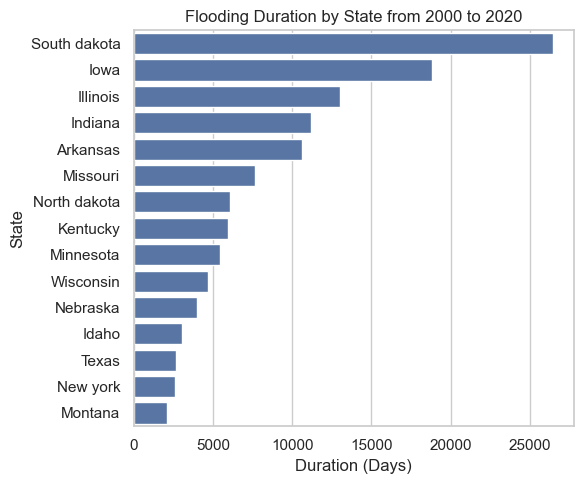

In [413]:
flood_state_duration_sorted = flood_state.sort_values(
    by="TOTAL_DURATION_HOURS", ascending=False
)
plot.figure(figsize=(6, 5))
plot.title("Flooding Duration by State from 2000 to 2020")
plot.ylabel("State")
plot.xlabel("Duration (Days)")
to_plot = flood_state_duration_sorted.head(15)
sns.barplot(y=to_plot["STATE"], x=to_plot["TOTAL_DURATION_HOURS"] / 24)
plot.tight_layout()
plot.show()

In [ ]:
import pandas as pd


def compute_state_year_correlation(hpi_df, flood_df):

    flood_df["FIPS"] = flood_df["FIPS"].astype(str).str.zfill(5)
    flood_df["YEAR"] = flood_df["YEAR"].astype(int)
    hpi_df["place_id"] = hpi_df["place_id"].astype(str).str.zfill(5)
    hpi_df["yr"] = hpi_df["yr"].astype(int)

    # --- Aggregate ---
    flood_state_year = flood_df.groupby(["FIPS", "YEAR"], as_index=False).agg(
        {"TOTAL_DAMAGE_PROPERTY": "sum"}
    )

    hpi_state_year = hpi_df.groupby(["place_id", "yr"], as_index=False).agg(
        {"index_nsa": "mean"}
    )

    print(flood_state_year.head())
    print(hpi_state_year.head())

    # --- Merge ---
    merged = pd.merge(
        flood_state_year,
        hpi_state_year,
        left_on=["FIPS", "YEAR"],
        right_on=["place_id", "yr"],
        how="inner",
    )

    print(merged.head())
    # --- Correlation by state ---
    corr_by_state = (
        merged.groupby("FIPS")[["TOTAL_DAMAGE_PROPERTY", "index_nsa"]]
        .corr()
        .iloc[0::2, -1]
        .reset_index()
        .rename(columns={"level_1": "Metric", "index_nsa": "CORRELATION"})
    )

    print(corr_by_state.head())

    # --- Correlation by year ---
    corr_by_year = (
        merged.groupby("YEAR")[["TOTAL_DAMAGE_PROPERTY", "index_nsa"]]
        .corr()
        .iloc[0::2, -1]
        .reset_index()
        .rename(columns={"level_1": "Metric", "index_nsa": "CORRELATION"})
    )
    print(corr_by_year.head())
    return {
        "corr_by_state": corr_by_state,
        "corr_by_year": corr_by_year,
        "merged": merged,
    }

In [418]:
hpi = pd.read_csv(
    "../../01_original_data/federal_housing_finance_agency/hpi_master.csv"
)
# print(min(hpi["yr"]))
hpi = hpi[hpi["level"] == "MSA"]  # only keep data for msa level
hpi = hpi[["place_name", "place_id", "yr", "period", "index_nsa"]]
hpi.head()

,place_name,place_id,yr,period,index_nsa
4140,"Abilene, TX",10180,1986,2,108.04
4141,"Abilene, TX",10180,1986,3,108.27
4142,"Abilene, TX",10180,1986,4,94.80
4143,"Abilene, TX",10180,1987,1,101.62
4144,"Abilene, TX",10180,1987,2,100.88


In [ ]:
results = compute_state_year_correlation(hpi, flood)

corr_state = results["corr_by_state"]
corr_year = results["corr_by_year"]

print("\n🔹 Correlation per state:\n", corr_state.head())
print("\n🔹 Correlation per year:\n", corr_year.head())

    FIPS  YEAR  TOTAL_DAMAGE_PROPERTY
0  01001  2000               200000.0
1  01001  2001                37000.0
2  01001  2003                58000.0
3  01001  2004                 8000.0
4  01001  2005                19000.0
  place_id    yr   index_nsa
0    10180  1986  103.703333
1    10180  1987   97.947500
2    10180  1988   84.570000
3    10180  1989   82.580000
4    10180  1990   80.892500
Empty DataFrame
Columns: [FIPS, YEAR, TOTAL_DAMAGE_PROPERTY, place_id, yr, index_nsa]
Index: []
Empty DataFrame
Columns: [FIPS, CORRELATION]
Index: []
Empty DataFrame
Columns: [YEAR, CORRELATION]
Index: []

🔹 Correlation per state:
 Empty DataFrame
Columns: [FIPS, CORRELATION]
Index: []

🔹 Correlation per year:
 Empty DataFrame
Columns: [YEAR, CORRELATION]
Index: []


In [303]:
# tornado = storm[storm["EVTYPE"].str.contains("tornado", case=False)]
# fire = storm[storm["EVTYPE"].str.contains("fire", case=False)]